# 03. Modeling : DAY 1 설계서대로 학습·평가

설계서(`docs/DS-MINI-Design-울산_4반-이채목+이진우.pdf`)에서 고정한 것을 그대로 구현한다. 테스트 결과를 보고 모델·피처를 바꾸지 않는다.

| 항목 | 설계서 | 구현 |
|---|---|---|
| 태스크·타깃 | 회귀, log10(cycle life), MAPE (S1) | `src/train.py` |
| 주 모델 | F1 = dq_var 하나 선형회귀 (S1·S2) | `MODELS[0]` |
| 함께 보고 (필수) | 확장 1순위 F1 + qd_c2_bc, 2피처, 기준선 2개 (S5) | `MODELS[1:5]` |
| 선택 | F2·F3·F4 (첨도·2V 논문 정의), 표준화 민감도, 트리 (S5) | `MODELS[5:]` |
| 분할 | Batch 1 정책 단위 train 32셀 / valid 9셀, 시드 42 (S4) | `src/split.py` |
| Train | train 32셀 정책 단위 GroupKFold(5), 튜닝은 안쪽 GroupKFold(4) (S4·A15) | `run_cv` |
| Valid | train 32셀 모델로 9셀 평가, 셀 단위 부트스트랩 2000회 95% 구간 (S4) | `evaluate` |
| Test | 같은 절차를 Batch 1 41셀 전체로 다시 학습한 최종 모델로 Batch 2·3 한 번 (S1·S3 "학습 41셀") | `evaluate` |
| 예측구간 | CV 폴드 밖 잔차(log10) 10·90% 분위수, 80% (S4) | `evaluate` |
| Gap | (+) 가 나빠짐이 되도록 Valid−Train, Test−Valid, Test−Target | `format_table` |

32셀 모델과 41셀 모델의 Batch 2 예측 차이는 테스트 전에 라벨 없이 재 두었다 : F1 0.99배, 확장 1순위 0.996배.

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
from scipy.stats import spearmanr
import train as T

FONT = '/System/Library/Fonts/AppleSDGothicNeo.ttc'
fm.fontManager.addfont(FONT)
plt.rcParams['font.family'] = fm.FontProperties(fname=FONT).get_name()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.spines.top'] = False; plt.rcParams['axes.spines.right'] = False
FIG = '../results/figures'
pd.set_option('display.width', 200)

T.main()   # 학습·평가 (결정적 실행 : 다시 돌려도 같은 숫자)

train 32셀·17정책 / valid 9셀·5정책 / Batch 1 41 / Batch 2 39 / Batch 3 40
F1                                 CV  8.93 ± 3.10  Valid 10.41  B2  26.17  B3  13.25
F1 + qd_c2_bc                      CV  6.63 ± 2.83  Valid  6.63  B2  26.56  B3  12.79
2피처 (F1 + qd_c2)                   CV  6.63 ± 2.83  Valid  6.63  B2  45.80  B3  10.53
기준선 : 학습 평균                        CV 28.29 ± 8.39  Valid 24.22  B2  73.24  B3  18.79


기준선 : 용량 곡선 7개 ElasticNet          CV 23.61 ± 4.94  Valid 22.37  B2 185.40  B3  36.06
F1 + qd_c2_bz                      CV  6.63 ± 2.83  Valid  6.63  B2  25.93  B3  12.88


F2 ElasticNet                      CV 10.75 ± 7.17  Valid 10.58  B2  30.38  B3  12.71


F2 Ridge                           CV 11.72 ± 7.74  Valid 10.53  B2  29.90  B3  15.89


F3 ElasticNet                      CV  8.84 ± 5.31  Valid 10.75  B2  33.45  B3   9.72


F3 Ridge                           CV  9.35 ± 5.51  Valid 13.94  B2  28.81  B3  14.93


F4 ElasticNet                      CV  9.36 ± 4.55  Valid  9.70


F1 RandomForest                    CV 15.34 ± 8.94  Valid 14.49  B2  32.10  B3  12.92


F1 XGBoost                         CV 16.42 ± 7.70  Valid 15.45  B2  39.55  B3  20.75
                      구분                  세부  MAPE (%)                                                                                                       비고
      Train (Batch 1 CV)                          8.93                                                               train 32셀 정책 단위 GroupKFold(5), 폴드 표준편차 3.1
Valid (Batch 1 Hold-out)                         10.41                                                             9셀·5정책 (train 32셀 모델), 부트스트랩 95% 구간 4.7~17.5
          Test (Batch 2)                         26.17                                                                        Batch 1 41셀로 다시 학습한 최종 모델, 한 번 평가
                           Gap (Train-Valid)      1.48                                                                              Valid - Train. (+) : 과적합 의심
                            Gap (Valid-Test)     15.76                                                            

In [2]:
perf = pd.read_csv('../results/model_performance.csv')
comp = pd.read_csv('../results/model_comparison.csv')
p = pd.read_csv('../results/predictions.csv')
p['t'], p['q'] = 10 ** p.y_log, 10 ** p.p_log
p['ape'] = (p.q - p.t).abs() / p.t * 100
p['over'] = p.q > p.t
p['ratio'] = p.t / p.q   # 실제 / 예측 : 1 보다 작으면 과대 예측
p['grp'] = np.select([p.batch.eq('b1'), p.batch.eq('b2') & p.newstructure, p.batch.eq('b2')],
                     ['Batch 1', 'Batch 2 newstructure', 'Batch 2 일반'], 'Batch 3')
KEY = ['F1', 'F1 + qd_c2_bc', '2피처 (F1 + qd_c2)']

## 1. 성능표 (과제 포맷, 주 모델 F1)

In [3]:
perf

,구분,세부,MAPE (%),비고
0,Train (Batch 1 CV),NaN,8.93,"train 32셀 정책 단위 GroupKFold(5), 폴드 표준편차 3.1"
1,Valid (Batch 1 Hold-out),NaN,10.41,"9셀·5정책 (train 32셀 모델), 부트스트랩 95% 구간 4.7~17.5"
2,Test (Batch 2),NaN,26.17,"Batch 1 41셀로 다시 학습한 최종 모델, 한 번 평가"
3,NaN,Gap (Train-Valid),1.48,Valid - Train. (+) : 과적합 의심
4,NaN,Gap (Valid-Test),15.76,Test - Valid. (+) : 배치간 일반화 저하 의심
5,NaN,Gap (Target-Test),17.07,Test - Target. Target : 원논문 9.1%. 같은 구조 varian...
6,Test (Batch 3),NaN,13.25,추가 검증. 규칙 ① 에 쓰지 않은 배치
7,NaN,Gap (Batch2-Batch3),-12.92,Batch 3 - Batch 2. Test 성능 간 비교
8,NaN,Gap (Target-Test),4.15,Batch 3 기준 Test - Target(9.1%). Batch 3 는 원논문 ...


## 2. 모델 비교

필수(주 모델·확장 1순위·비교·기준선)와 선택을 함께 둔다. F4 는 Batch 2 내부저항 6셀이 결측이라 Batch 1 비교에만 쓴다 (설계서 S1).

In [4]:
cols = ['model', 'role', 'n_feat', 'cv_mape', 'cv_std', 'valid_mape', 'valid_ci_lo', 'valid_ci_hi', 'b2_mape', 'b3_mape']
comp[cols].round(2)

,model,role,n_feat,cv_mape,cv_std,valid_mape,valid_ci_lo,valid_ci_hi,b2_mape,b3_mape
0,F1,주 모델,1,8.93,3.10,10.41,4.70,17.54,26.17,13.25
1,F1 + qd_c2_bc,확장 1순위,2,6.63,2.83,6.63,3.05,10.92,26.56,12.79
2,2피처 (F1 + qd_c2),비교,2,6.63,2.83,6.63,3.05,10.92,45.80,10.53
3,기준선 : 학습 평균,기준선,1,28.29,8.39,24.22,9.44,40.77,73.24,18.79
4,기준선 : 용량 곡선 7개 ElasticNet,기준선,7,23.61,4.94,22.37,9.53,38.61,185.40,36.06
5,F1 + qd_c2_bz,선택 : 표준화 민감도,2,6.63,2.83,6.63,3.05,10.92,25.93,12.88
6,F2 ElasticNet,선택 : 확장 후보,5,10.75,7.17,10.58,5.21,16.23,30.38,12.71
7,F2 Ridge,선택 : 규제 비교,5,11.72,7.74,10.53,5.21,16.10,29.90,15.89
8,F3 ElasticNet,선택 : 확장 후보,13,8.84,5.31,10.75,6.43,16.13,33.45,9.72
9,F3 Ridge,선택 : 규제 비교,13,9.35,5.51,13.94,8.67,20.01,28.81,14.93


## 3. 예측 대 실제

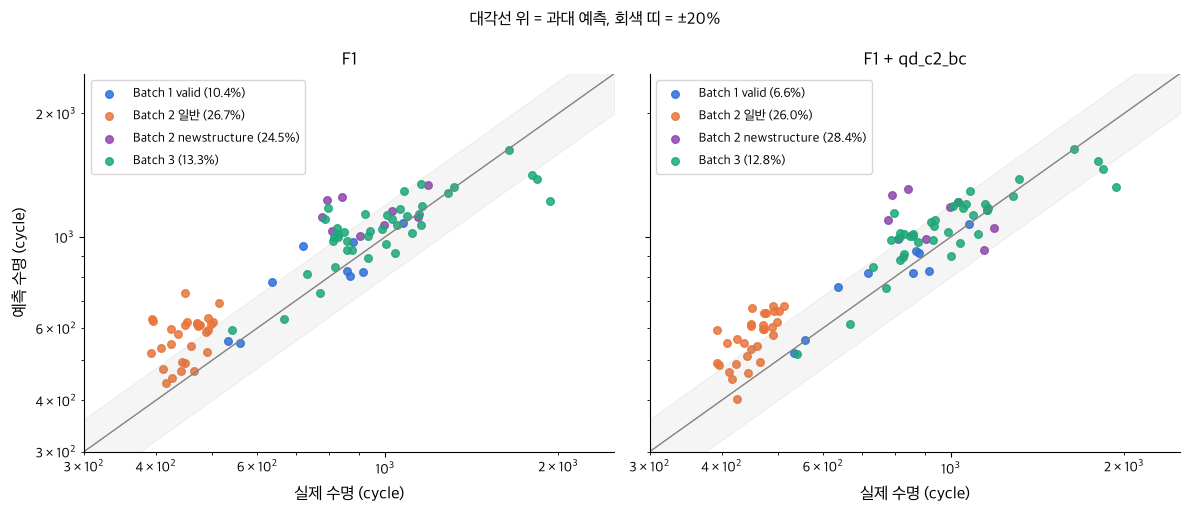

In [5]:
COL = {'Batch 1': '#2a6fdb', 'Batch 2 일반': '#e8743b', 'Batch 2 newstructure': '#8e44ad', 'Batch 3': '#19a979'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True)
for ax, m in zip(axes, ['F1', 'F1 + qd_c2_bc']):
    u = p[(p.model == m) & p.split.isin(['valid', 'b2', 'b3'])]
    for g, c in COL.items():
        v = u[u.grp == g]
        lab = 'Batch 1 valid' if g == 'Batch 1' else g
        ax.scatter(v.t, v.q, s=30, color=c, alpha=0.85, label=f'{lab} ({v.ape.mean():.1f}%)')
    lim = [300, 2500]
    ax.plot(lim, lim, color='grey', lw=1)
    ax.fill_between(lim, [x * 0.8 for x in lim], [x * 1.2 for x in lim], color='grey', alpha=0.08)
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('실제 수명 (cycle)', fontsize=12); ax.set_title(m, fontsize=13)
    ax.legend(fontsize=9.5, loc='upper left')
axes[0].set_ylabel('예측 수명 (cycle)', fontsize=12)
fig.suptitle('대각선 위 = 과대 예측, 회색 띠 = ±20%', fontsize=12)
plt.tight_layout(); plt.savefig(f'{FIG}/day2_pred_vs_actual.png', bbox_inches='tight'); plt.show()

## 4. Batch 2 집단별 오차와 과대 예측 (설계서 S5)

과대 예측 비율 = 예측이 실제보다 긴 셀의 비율. 실제/예측 = 셀별 비의 중앙값 (1 보다 작으면 과대 예측).

In [6]:
t4 = (p[p.model.isin(KEY + ['F1 + qd_c2_bz']) & p.split.isin(['valid', 'b2', 'b3'])]
      .groupby(['grp', 'model']).agg(n=('ape', 'size'), MAPE=('ape', 'mean'), 과대예측=('over', 'mean'), 실제_예측=('ratio', 'median')))
t4.round(3)

n    MAPE   과대예측  실제_예측
grp                  model                                     
Batch 1              2피처 (F1 + qd_c2)   9   6.633  0.556  0.996
                     F1                 9  10.405  0.556  0.991
                     F1 + qd_c2_bc      9   6.633  0.556  0.996
                     F1 + qd_c2_bz      9   6.633  0.556  0.996
Batch 2 newstructure 2피처 (F1 + qd_c2)   9  43.156  0.889  0.721
                     F1                 9  24.525  0.889  0.888
                     F1 + qd_c2_bc      9  28.371  0.778  0.841
                     F1 + qd_c2_bz      9  27.221  0.778  0.851
Batch 2 일반           2피처 (F1 + qd_c2)  30  46.595  1.000  0.680
                     F1                30  26.670  1.000  0.778
                     F1 + qd_c2_bc     30  26.016  0.967  0.793
                     F1 + qd_c2_bz     30  25.536  0.967  0.786
Batch 3              2피처 (F1 + qd_c2)  40  10.529  0.350  1.062
                     F1                40  13.253  0.675  0.937
                     F1 + qd_c2_bc     40  12.787  0.725  0.927
                     F1 + qd_c2_bz     40  12.875  0.700  0.931

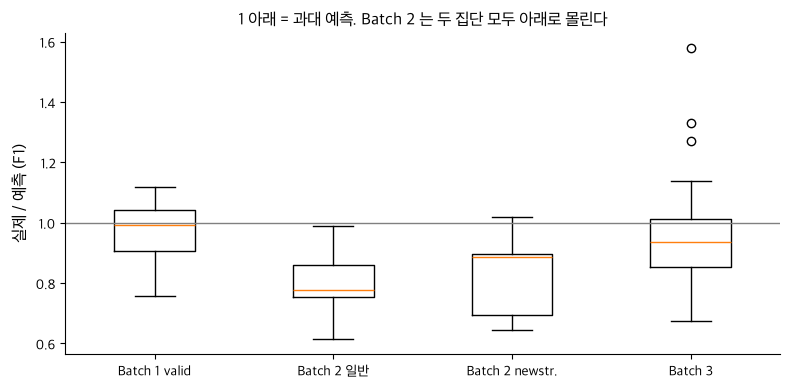

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
u = p[(p.model == 'F1') & p.split.isin(['valid', 'b2', 'b3'])]
order = ['Batch 1', 'Batch 2 일반', 'Batch 2 newstructure', 'Batch 3']
ax.boxplot([u[u.grp == g].ratio for g in order], tick_labels=['Batch 1 valid', 'Batch 2 일반', 'Batch 2 newstr.', 'Batch 3'])
ax.axhline(1, color='grey', lw=1); ax.set_ylabel('실제 / 예측 (F1)', fontsize=12)
ax.set_title('1 아래 = 과대 예측. Batch 2 는 두 집단 모두 아래로 몰린다', fontsize=12)
plt.tight_layout(); plt.savefig(f'{FIG}/day2_ratio_by_group.png', bbox_inches='tight'); plt.show()

## 5. 80% 예측구간 (설계서 S4) : 실제 수명이 구간 안·하한 아래에 든 비율 (F1)

In [8]:
f1 = p[p.model == 'F1'].copy()
f1['in_pi'] = (f1.y_log >= f1.pi_lo_log) & (f1.y_log <= f1.pi_hi_log)
f1['below'] = f1.y_log < f1.pi_lo_log
f1.groupby('split').agg(n=('in_pi', 'size'), 포함=('in_pi', 'mean'), 하한아래=('below', 'mean')).loc[['cv_oof', 'valid', 'b2', 'b3']].round(2)

,n,포함,하한아래
split,,,
cv_oof,32,0.75,0.12
valid,9,0.78,0.22
b2,39,0.31,0.69
b3,40,0.60,0.30


## 6. Batch 1 범위 밖 셀 (설계서 S5·부록 A10)

Batch 2 셀 중 dq_var 가 Batch 1 41셀의 범위 밖인 셀의 오차를 따로 본다.

In [9]:
b1x = p[(p.model == 'F1') & (p.batch == 'b1')].drop_duplicates('cell')
lo, hi = b1x.dq_var.min(), b1x.dq_var.max()
u = p[p.model.isin(KEY) & (p.split == 'b2')].copy()
u['범위'] = np.where((u.dq_var < lo) | (u.dq_var > hi), '밖', '안')
print(f'Batch 1 dq_var 범위 {lo:.2f} ~ {hi:.2f}. 범위 밖 Batch 2 셀은 모두 dq_var 가 더 크다 :', bool((u[u.범위 == '밖'].dq_var > hi).all()))
u.groupby(['model', '범위', 'grp']).agg(n=('ape', 'size'), MAPE=('ape', 'mean'), 실제_예측=('ratio', 'median')).round(2)

Batch 1 dq_var 범위 -5.01 ~ -3.35. 범위 밖 Batch 2 셀은 모두 dq_var 가 더 크다 : True


n   MAPE  실제_예측
model            범위 grp                                   
2피처 (F1 + qd_c2) 밖  Batch 2 일반            11  33.59   0.74
                 안  Batch 2 newstructure   9  43.16   0.72
                    Batch 2 일반            19  54.12   0.65
F1               밖  Batch 2 일반            11  13.27   0.91
                 안  Batch 2 newstructure   9  24.52   0.89
                    Batch 2 일반            19  34.43   0.77
F1 + qd_c2_bc    밖  Batch 2 일반            11  15.52   0.86
                 안  Batch 2 newstructure   9  28.37   0.84
                    Batch 2 일반            19  32.09   0.76

## 7. 정책 내 오차와 하한 (설계서 S5)

F1 의 Batch 1 CV 폴드 밖 잔차를 같은 정책 안에서만 본다. 비교 기준은 정책만 알 때의 하한 (train 32셀 log10 수명의 정책 내 pooled 표준편차, 01_EDA).

In [10]:
def pooled_sd(df, col):
    df = df.groupby('policy').filter(lambda x: len(x) >= 2)
    dev = df[col] - df.groupby('policy')[col].transform('mean')
    return np.sqrt((dev ** 2).sum() / (len(df) - df.policy.nunique())), len(df), df.policy.nunique()

def as_mape(sd):
    e = np.random.default_rng(0).normal(0, sd, 2_000_000)
    return np.mean(np.abs(10 ** -e - 1)) * 100

o = p[(p.model == 'F1') & (p.split == 'cv_oof')].copy()
o['resid'] = o.y_log - o.p_log
sd_r, n, P = pooled_sd(o, 'resid')
sd_y, _, _ = pooled_sd(o, 'y_log')
print(f'정책 2셀 이상 {n}셀·{P}정책')
print(f'수명 자체의 정책 내 sd (하한) : {sd_y:.4f} → MAPE 환산 {as_mape(sd_y):.1f}%')
print(f'F1 잔차의 정책 내 sd         : {sd_r:.4f} → MAPE 환산 {as_mape(sd_r):.1f}%')

정책 2셀 이상 29셀·14정책
수명 자체의 정책 내 sd (하한) : 0.0345 → MAPE 환산 6.4%
F1 잔차의 정책 내 sd         : 0.0461 → MAPE 환산 8.5%


## 8. 배치 안 순위 : 확장 1순위가 F1 보다 나은가 (설계서 부록 A11)

확장 1순위는 배치 평균 예측을 거의 움직이지 않고 배치 안 순위만 바꾼다. 그 관계가 다른 배치에서도 성립하는지 순위 상관으로 본다.

In [11]:
rows = []
for g in ['Batch 2 일반', 'Batch 2 newstructure', 'Batch 3']:
    for m in ['F1', 'F1 + qd_c2_bc', 'F1 + qd_c2_bz', '2피처 (F1 + qd_c2)']:
        v = p[(p.model == m) & (p.grp == g)]
        rows.append({'집단': g, 'n': len(v), 'model': m, 'Spearman(예측, 실제)': spearmanr(v.p_log, v.y_log).correlation})
pd.DataFrame(rows).pivot(index='집단', columns='model', values='Spearman(예측, 실제)').round(2)

model,2피처 (F1 + qd_c2),F1,F1 + qd_c2_bc,F1 + qd_c2_bz
집단,,,,
Batch 2 newstructure,-0.33,0.17,-0.33,-0.20
Batch 2 일반,0.75,0.38,0.75,0.69
Batch 3,0.84,0.76,0.84,0.84


## 9. 재보정 시나리오 (설계서 S4·S5, 본 평가와 분리)

운영에서 새 배치의 일부 셀 수명이 먼저 끝나면, 그 셀로 F1 의 절편만 맞춘다. 재보정에 쓴 셀은 평가에서 뺀다.
가장 먼저 끝난 셀은 짧은 쪽으로 치우친 선택이라 무작위 5셀(시드 42)을 대조로 둔다.

In [12]:
b2 = p[(p.model == 'F1') & (p.split == 'b2')].copy()
b2['resid'] = b2.y_log - b2.p_log
def recal(sel_idx):
    shift = b2.loc[sel_idx, 'resid'].mean()
    rest = b2.drop(sel_idx)
    ape = (10 ** (rest.p_log + shift) - rest.t).abs() / rest.t * 100
    return {'절편 이동 (배)': 10 ** shift, '평가 셀': len(rest), '재보정 전 MAPE': rest.ape.mean(), '재보정 후 MAPE': ape.mean(),
            '후 : 일반': ape[rest.grp == 'Batch 2 일반'].mean(), '후 : newstructure': ape[rest.grp == 'Batch 2 newstructure'].mean()}
early, rnd = b2.nsmallest(5, 't').index, b2.sample(5, random_state=42).index
print('먼저 끝난 5셀 :', b2.loc[early, 'cell'].tolist(), '| 무작위 5셀 :', b2.loc[rnd, 'cell'].tolist())
pd.DataFrame({'먼저 끝난 5셀': recal(early), '무작위 5셀': recal(rnd)}).T.round(3)

먼저 끝난 5셀 : ['b2c19', 'b2c6', 'b2c15', 'b2c21', 'b2c30'] | 무작위 5셀 : ['b2c41', 'b2c44', 'b2c4', 'b2c13', 'b2c32']


,절편 이동 (배),평가 셀,재보정 전 MAPE,재보정 후 MAPE,후 : 일반,후 : newstructure
먼저 끝난 5셀,0.721,34.0,24.175,13.002,12.083,15.555
무작위 5셀,0.822,34.0,26.709,11.488,10.742,14.365


## 10. 오류 분석 : 가장 크게 틀린 셀 (F1)

In [13]:
top = (p[(p.model == 'F1') & p.split.isin(['b2', 'b3'])].nlargest(10, 'ape')
       [['cell', 'grp', 'policy', 't', 'q', 'ape', 'over', 'dq_var']].round(2))
print('상위 10셀 중 과대 예측', int(top.over.sum()), '셀 | 집단 :', top.grp.value_counts().to_dict())
top

상위 10셀 중 과대 예측 10 셀 | 집단 : {'Batch 2 일반': 5, 'Batch 2 newstructure': 3, 'Batch 3': 2}


,cell,grp,policy,t,q,ape,over,dq_var
59,b2c18,Batch 2 일반,5.2C(50%)-4.25C,449.00,730.48,62.69,True,-3.71
47,b2c6,Batch 2 일반,3.6C(9%)-5C,393.00,632.28,60.89,True,-3.53
56,b2c15,Batch 2 일반,3.6C(9%)-5C,396.00,625.22,57.88,True,-3.52
50,b2c9,Batch 2 newstructure,5.6C(26%)-4.5C-newstructure,791.01,1227.30,55.16,True,-4.34
77,b2c44,Batch 2 newstructure,5.2C(58%)-4C-newstructure,841.01,1247.56,48.34,True,-4.36
116,b3c40,Batch 3,5.6C(19%)-4.6C-newstructure,795.99,1178.99,48.12,True,-4.30
48,b2c7,Batch 2 newstructure,4.8C(80%)-4.8C-newstructure,777.00,1119.62,44.10,True,-4.23
117,b3c41,Batch 3,5.6C(36%)-4.3C-newstructure,786.00,1108.59,41.04,True,-4.22
43,b2c2,Batch 2 일반,5.2C(50%)-4.25C,424.00,597.35,40.88,True,-3.46
68,b2c29,Batch 2 일반,5.2C(58%)-4C,452.00,621.16,37.42,True,-3.51


## 11. 선택 모델 : 첨도·2V 를 논문 정의로 바꾼 CV (설계서 S4 구현 명세)

같은 train 32셀·같은 폴드에서 DAY 1 정의(초과첨도 절댓값, 2V 원래 값)와 논문 정의(일반 첨도, log10|ΔQ(2V)|)를 나란히 본다. Batch 2·3 는 쓰지 않는다.

In [14]:
from features import model_table
from split import split_b1
df = model_table(); b1 = df[df.batch == 'b1'].reset_index(drop=True)
train, valid = split_b1(b1); train = train.reset_index(drop=True)
DQ_OLD = ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt']
sets = {'F2': (DQ_OLD, T.DQ_P), 'F3': (DQ_OLD + ['dq_2v'] + T.CAP, T.DQ_P + ['dq_2v_p'] + T.CAP),
        'F4': (DQ_OLD + ['dq_2v'] + T.CAP + T.OTHER, T.DQ_P + ['dq_2v_p'] + T.CAP + T.OTHER)}
rows = []
for fs, (old, new) in sets.items():
    for mk, mname in [(T.enet, 'ElasticNet'), (T.ridge, 'Ridge')]:
        r = {'세트': fs, '모델': mname}
        for lab, cols in [('DAY 1 정의', old), ('논문 정의', new)]:
            s, _ = T.run_cv(dict(name='x', cols=cols, make=mk), train)
            r[lab] = round(s.mean(), 2)
        rows.append(r)
cvdef = pd.DataFrame(rows)
f1cv = comp.loc[comp.model == 'F1', 'cv_mape'].iloc[0]
print(f'F1 선형 CV {f1cv:.2f}. 1-SE 기준 {f1cv + comp.loc[comp.model == "F1", "cv_std"].iloc[0] / np.sqrt(5):.2f}')
cvdef

F1 선형 CV 8.93. 1-SE 기준 10.32


,세트,모델,DAY 1 정의,논문 정의
0,F2,ElasticNet,10.26,10.75
1,F2,Ridge,10.77,11.72
2,F3,ElasticNet,8.97,8.84
3,F3,Ridge,11.11,9.35
4,F4,ElasticNet,9.34,9.36
5,F4,Ridge,11.73,12.45


## 12. Batch 3 와 Gap(Batch2-Batch3)

In [15]:
u = p[p.model.isin(KEY) & (p.split == 'b3')]
print('Batch 3 는 원논문 secondary test 와 같은 2018-04-12 배치 40셀. 논문 variance 모델 secondary 11.4%')
pt = pd.read_csv('../results/procedure_timing.csv').merge(df[['cell', 'newstructure']], on='cell')
pt['grp'] = pt.cell.str[:2].map({'b1': 'Batch 1', 'b2': 'Batch 2', 'b3': 'Batch 3'}) + np.where(pt.newstructure, ' newstructure', ' 일반')
display(u.groupby('model').agg(MAPE=('ape', 'mean'), 과대예측=('over', 'mean'), 실제_예측=('ratio', 'median')).round(3))
pt.groupby('grp')[['cycle_min', 'rest_min']].median().round(1)

Batch 3 는 원논문 secondary test 와 같은 2018-04-12 배치 40셀. 논문 variance 모델 secondary 11.4%


,MAPE,과대예측,실제_예측
model,,,
2피처 (F1 + qd_c2),10.529,0.350,1.062
F1,13.253,0.675,0.937
F1 + qd_c2_bc,12.787,0.725,0.927


,cycle_min,rest_min
grp,,
Batch 1 일반,52.0,1.0
Batch 2 newstructure,48.4,0.3
Batch 2 일반,69.2,9.9
Batch 3 newstructure,46.6,0.3


## 13. ESS 해석용 환산 (설계서 부록 A13)

교체 준비 규칙 : 80% 예측구간 하한 × (knee 비율 최솟값) 시점부터 교체를 준비한다.
설계서는 세 배치 knee 범위의 최솟값 0.55 를 적었지만, 그 값은 Batch 2 의 수명(정답)에서 나온 것이라 같은 Batch 2 로 규칙을 확인하면 순환이 된다.
설계 원칙(결정은 Batch 1 과 라벨 없는 입력만)에 맞게 **Batch 1 셀의 knee 비율 최솟값**으로 정한다.

In [16]:
from features import load_cells, knee_point
b1cells = {k: c for k, c in load_cells(('b1',)).items() if c['exclude'] == '' and not c['carryover']}  # c0~c4 는 EOL 구간이 없어 제외
knee_ratio = pd.Series({k: knee_point(c)[0] / c['life_raw'] for k, c in b1cells.items()}).dropna()
KNEE_B1 = knee_ratio.min()
print(f'Batch 1 knee 비율 : 최솟값 {KNEE_B1:.3f}, 중앙값 {knee_ratio.median():.3f} ({len(knee_ratio)}셀)')

rows = []
for s, nm in [('valid', 'Batch 1 valid'), ('b2', 'Batch 2'), ('b3', 'Batch 3')]:
    v = f1[f1.split == s]
    med = v.t.median()
    prep = KNEE_B1 * 10 ** v.pi_lo_log    # 교체 준비 시작 시점 (cycle)
    rows.append({'구분': nm, 'n': len(v), '수명 중앙값': med, 'MAPE (%)': v.ape.mean(),
                 '중앙값 기준 오차 (cycle)': med * v.ape.mean() / 100, '하루 1회 가정 (개월)': med * v.ape.mean() / 100 / 30,
                 '과대 예측 비율': v.over.mean(),
                 '준비 시작 전에 수명이 끝난 셀': int((v.t < prep).sum()),
                 '준비 시작 / 실제 수명 (중앙값)': (prep / v.t).median()})
pd.DataFrame(rows).round(2)

Batch 1 knee 비율 : 최솟값 0.653, 중앙값 0.709 (36셀)


,구분,n,수명 중앙값,MAPE (%),중앙값 기준 오차 (cycle),하루 1회 가정 (개월),과대 예측 비율,준비 시작 전에 수명이 끝난 셀,준비 시작 / 실제 수명 (중앙값)
0,Batch 1 valid,9,860.00,10.41,89.48,2.98,0.56,0,0.58
1,Batch 2,39,472.00,26.17,123.54,4.12,0.97,0,0.74
2,Batch 3,40,964.51,13.25,127.82,4.26,0.68,0,0.62


준비가 너무 늦지는 않았는지 : 셀마다 실제 knee(평가용, 정답 사용)와 비교하고, 준비 시작에서 수명 종료까지 남은 사이클을 본다.

In [17]:
all_cells = load_cells()
rows = []
for s, nm in [('valid', 'Batch 1 valid'), ('b2', 'Batch 2'), ('b3', 'Batch 3')]:
    v = f1[f1.split == s].copy()
    v['prep'] = KNEE_B1 * 10 ** v.pi_lo_log
    v['knee'] = [knee_point(all_cells[c])[0] if not all_cells[c]['carryover'] else np.nan for c in v.cell]
    left = v.t - v.prep
    rows.append({'구분': nm, '준비 시작이 knee 이후인 셀 비율': (v.prep > v.knee).mean(),
                 '남은 사이클 최소': left.min(), '남은 비율 최소': (left / v.t).min(), '남은 비율 중앙값': (left / v.t).median()})
pd.DataFrame(rows).round(2)

,구분,준비 시작이 knee 이후인 셀 비율,남은 사이클 최소,남은 비율 최소,남은 비율 중앙값
0,Batch 1 valid,0.11,169.12,0.24,0.42
1,Batch 2,0.72,26.11,0.06,0.26
2,Batch 3,0.08,113.43,0.14,0.38
